In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

pd.options.display.float_format = '{:.3f}'.format

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [5]:
df= pd.read_csv("../../clean_data/filtered_icfes_data.csv")
df.head()


,periodo,estu_consecutivo,cole_area_ubicacion,cole_calendario,cole_cod_dane_sede,cole_jornada,cole_naturaleza,cole_nombre_sede,fami_educacionmadre,fami_educacionpadre,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,SB11202240152772,RURAL,A,320013001752,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA DIVINO NIÑO,Primaria completa,Primaria completa,A-,35.000,38.000,37.000,36.000,36.000,183.000
1,20224,SB11202240042820,RURAL,A,220614000431,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA AGROPECUARIA LOS ANGELES,Primaria completa,Primaria completa,A-,45.000,46.000,47.000,43.000,52.000,234.000
2,20224,SB11202240462114,URBANO,A,120400008286,MAÑANA,OFICIAL,INSTITUCION EDUCATIVA LUIS CARLOS GALAN SARMIENTO,Primaria incompleta,Primaria completa,A1,54.000,37.000,31.000,42.000,41.000,195.000
3,20224,SB11202240377474,RURAL,A,420013001749,MAÑANA,NO OFICIAL,FUNDACION EDUCATIVA NUESTRA SEÑORA DE LAS FLORES,Educación profesional completa,Educación profesional completa,A1,57.000,53.000,61.000,54.000,58.000,283.000
4,20224,SB11202240444419,URBANO,A,120238000136,NOCHE,OFICIAL,INSTITUCION EDUCATIVA INSTITUTO AGRICOLA,Secundaria (Bachillerato) incompleta,Secundaria (Bachillerato) completa,A-,31.000,33.000,39.000,41.000,35.000,183.000


In [6]:
# Contar NAs
nas= df.isna().any(axis=1).sum()
print(nas)

2675


In [7]:
print(f'Dimensiones: {df.shape}')
print(f'\nVariables: {list(df.columns)}')

Dimensiones: (77575, 17)

Variables: ['periodo', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_calendario', 'cole_cod_dane_sede', 'cole_jornada', 'cole_naturaleza', 'cole_nombre_sede', 'fami_educacionmadre', 'fami_educacionpadre', 'desemp_ingles', 'punt_ingles', 'punt_matematicas', 'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica', 'punt_global']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77575 entries, 0 to 77574
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   periodo                   77575 non-null  int64  
 1   estu_consecutivo          77575 non-null  str    
 2   cole_area_ubicacion       77575 non-null  str    
 3   cole_calendario           77575 non-null  str    
 4   cole_cod_dane_sede        77575 non-null  int64  
 5   cole_jornada              77575 non-null  str    
 6   cole_naturaleza           77575 non-null  str    
 7   cole_nombre_sede          77575 non-null  str    
 8   fami_educacionmadre       75050 non-null  str    
 9   fami_educacionpadre       75084 non-null  str    
 10  desemp_ingles             77508 non-null  str    
 11  punt_ingles               77508 non-null  float64
 12  punt_matematicas          77575 non-null  float64
 13  punt_sociales_ciudadanas  77575 non-null  float64
 14  punt_c_naturales 

In [9]:
# 3.1 Verificar valores faltantes
print('Valores faltantes por variable:')
print(df.isnull().sum())
print(f'\nTotal de valores faltantes: {df.isnull().sum().sum()}')

Valores faltantes por variable:
periodo                        0
estu_consecutivo               0
cole_area_ubicacion            0
cole_calendario                0
cole_cod_dane_sede             0
cole_jornada                   0
cole_naturaleza                0
cole_nombre_sede               0
fami_educacionmadre         2525
fami_educacionpadre         2491
desemp_ingles                 67
punt_ingles                   67
punt_matematicas               0
punt_sociales_ciudadanas       0
punt_c_naturales               0
punt_lectura_critica           0
punt_global                    0
dtype: int64

Total de valores faltantes: 5150


In [10]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
periodo,77575.000,20175.792,27.881,20142.000,20152.000,20172.000,20194.000,20224.000
cole_cod_dane_sede,77575.000,181518021217.003,85984029325.484,120001000018.000,120001800006.000,120400000111.000,220400008345.000,420710000301.000
punt_ingles,77508.000,47.970,10.963,0.000,41.000,47.000,53.000,100.000
punt_matematicas,77575.000,48.635,11.134,0.000,41.000,48.000,56.000,100.000
punt_sociales_ciudadanas,77575.000,47.117,10.933,0.000,39.000,47.000,55.000,100.000
punt_c_naturales,77575.000,48.708,9.892,0.000,42.000,48.000,55.000,100.000
punt_lectura_critica,77575.000,50.091,9.789,0.000,43.000,50.000,57.000,100.000
punt_global,77575.000,242.931,45.876,0.000,209.000,238.000,272.000,465.000


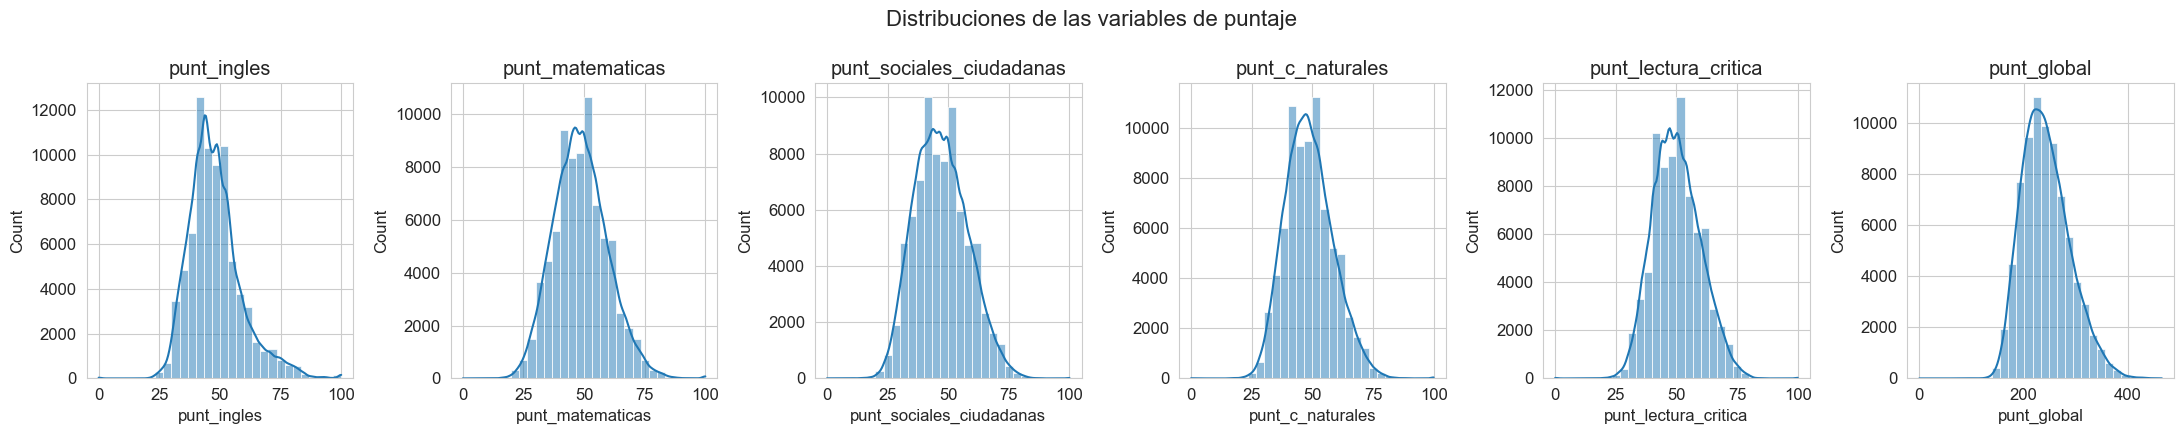

In [11]:
punt_cols = ['punt_ingles','punt_matematicas','punt_sociales_ciudadanas','punt_c_naturales','punt_lectura_critica','punt_global']

plt.figure(figsize=(22, 4))
for i, col in enumerate(punt_cols):
    plt.subplot(1, len(punt_cols), i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.suptitle('Distribuciones de las variables de puntaje', y=1.08, fontsize=16)
plt.show()

In [12]:
# Puntajes individuales
areas = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica"]

for col in areas:
    invalidos = df[(df[col] < 0) | (df[col] > 100)]
    print(f"\nValores inválidos en {col}: {len(invalidos)}")

# Puntaje global
invalidos_global = df[(df["punt_global"] < 0) | (df["punt_global"] > 500)]
print(f"\nValores inválidos en punt_global: {len(invalidos_global)}")


Valores inválidos en punt_ingles: 0

Valores inválidos en punt_matematicas: 0

Valores inválidos en punt_sociales_ciudadanas: 0

Valores inválidos en punt_c_naturales: 0

Valores inválidos en punt_lectura_critica: 0

Valores inválidos en punt_global: 0


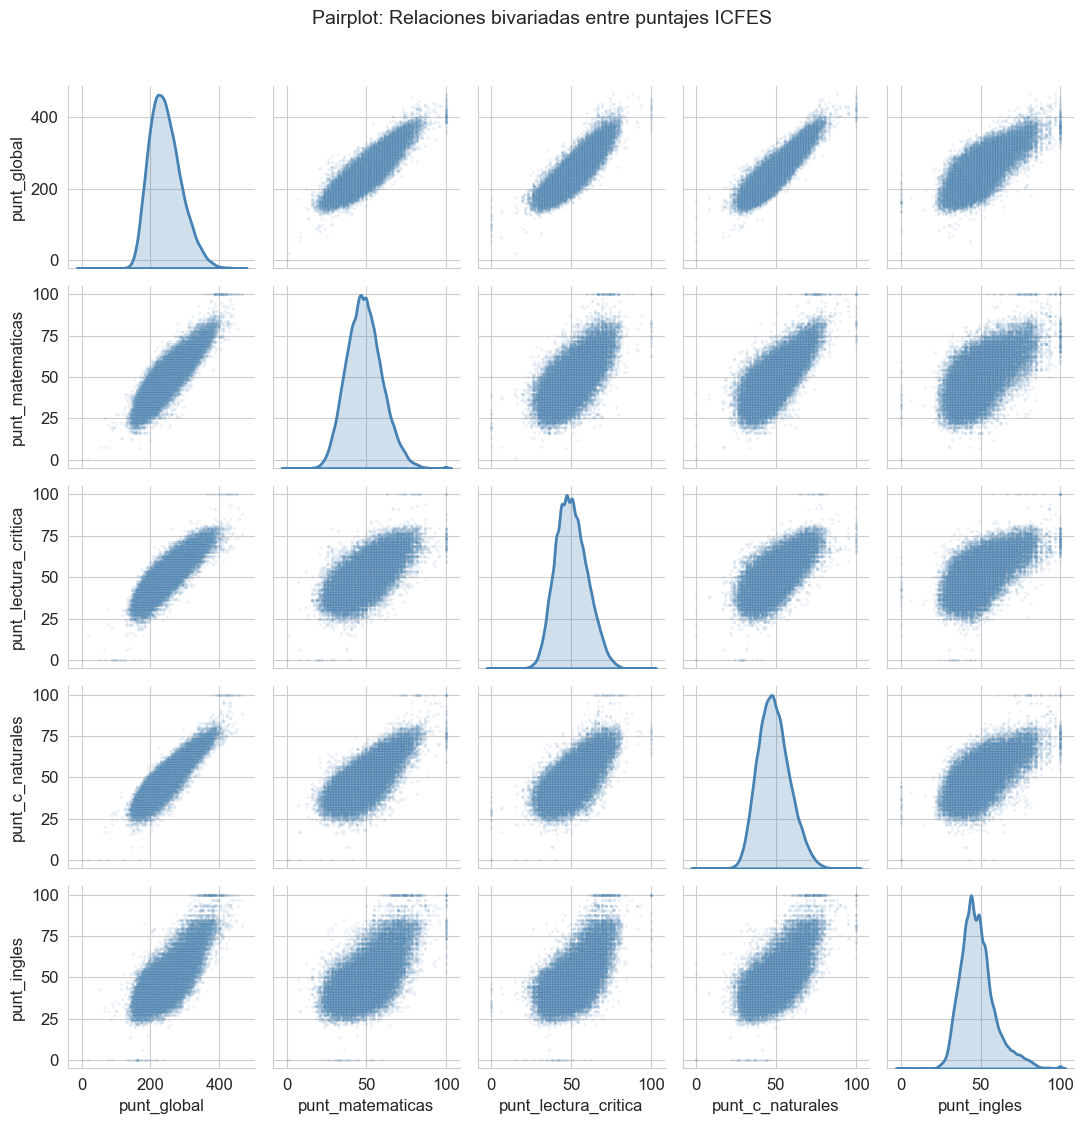

In [13]:
vars_pairplot = ["punt_global","punt_matematicas","punt_lectura_critica","punt_c_naturales","punt_ingles"]
g = sns.pairplot(df[vars_pairplot], diag_kind="kde", plot_kws={"alpha": 0.1, "s": 5, "color": "steelblue"}, diag_kws={"color": "steelblue", "linewidth": 2}, height=2.2, aspect=1)
g.figure.suptitle("Pairplot: Relaciones bivariadas entre puntajes ICFES", fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

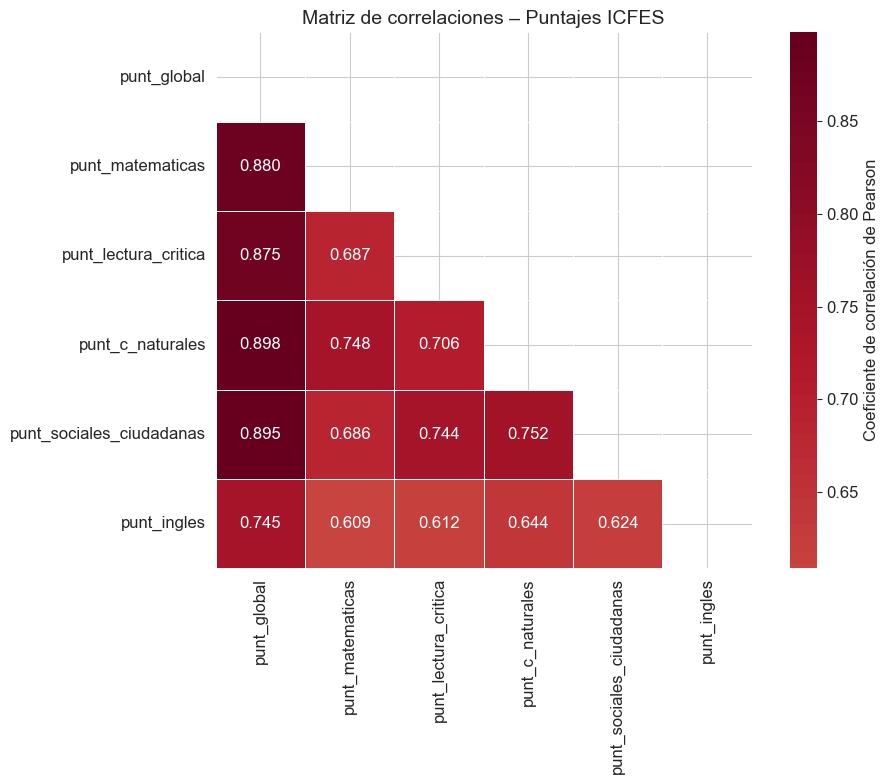

In [14]:
#Correlaciones
vars_corr = ["punt_global", "punt_matematicas", "punt_lectura_critica", "punt_c_naturales", "punt_sociales_ciudadanas","punt_ingles"]

# Calculamos matriz de correlación (Pearson recomendado aquí)
corr_matrix = df[vars_corr].corr(method="pearson")

# Graficamos
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"label":"Coeficiente de correlación de Pearson"})
ax.set_title("Matriz de correlaciones – Puntajes ICFES", fontsize=14)

plt.tight_layout()
plt.show()

cole_area_ubicacion
URBANO    65180
RURAL     12395
Name: count, dtype: int64


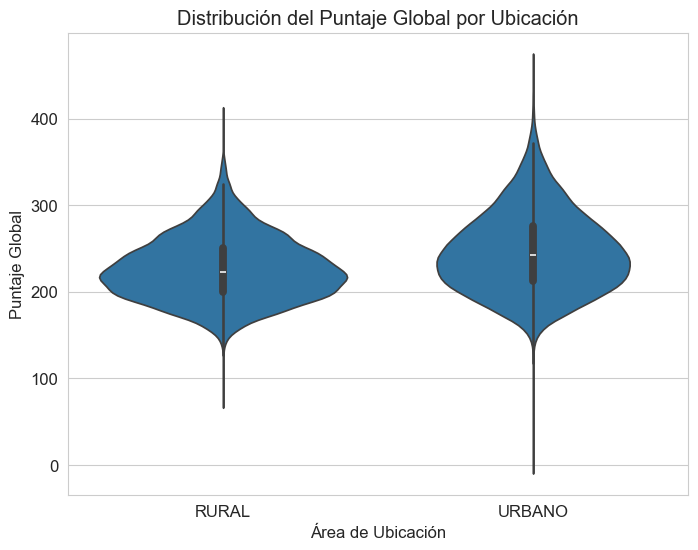

In [15]:
#Boxplots por categorías
ubi= df["cole_area_ubicacion"].value_counts()
print(ubi)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_area_ubicacion", y="punt_global", inner="box")

plt.title("Distribución del Puntaje Global por Ubicación")
plt.xlabel("Área de Ubicación")
plt.ylabel("Puntaje Global")
plt.show()

In [16]:
urbano = df[df["cole_area_ubicacion"] == "URBANO"]["punt_global"]
rural = df[df["cole_area_ubicacion"] == "RURAL"]["punt_global"]

mean1 = urbano.mean()
mean2 = rural.mean()
print("Media grupo 1:", mean1)
print("Media grupo 2:", mean2)
print("Diferencia:", mean1 - mean2)

t_stat, p_value = stats.ttest_ind(urbano, rural, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Media grupo 1: 246.02163240257747
Media grupo 2: 226.6771278741428
Diferencia: 19.34450452843467
t-statistic: 43.554750545561305
p-value: 0.0


cole_calendario
A    77203
B      372
Name: count, dtype: int64


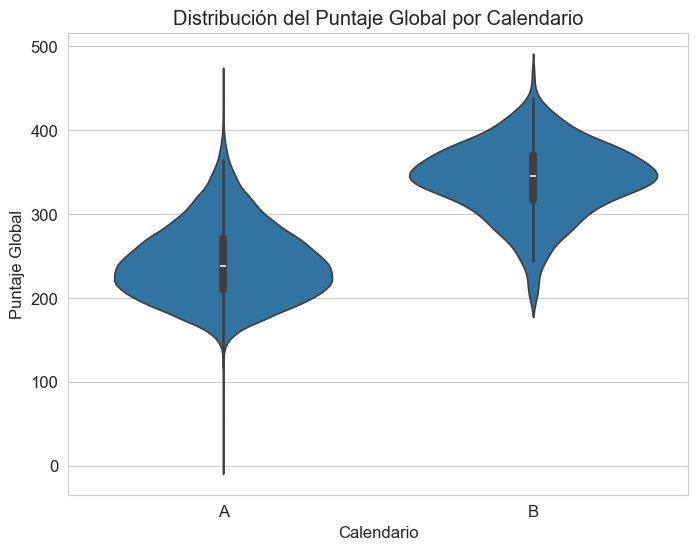

In [17]:
calend= df["cole_calendario"].value_counts()
print(calend)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_calendario", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Calendario")
plt.xlabel("Calendario")
plt.ylabel("Puntaje Global")
plt.show()

In [18]:
A = df[df["cole_calendario"] == "A"]["punt_global"]
B = df[df["cole_calendario"] == "B"]["punt_global"]

mean1 = A.mean()
mean2 = B.mean()
print("Media grupo 1:", mean1)
print("Media grupo 2:", mean2)
print("Diferencia:", mean1 - mean2)

t_stat, p_value = stats.ttest_ind(A, B, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Media grupo 1: 242.45626465292798
Media grupo 2: 341.4032258064516
Diferencia: -98.9469611535236
t-statistic: -44.35647883314396
p-value: 2.9269796099394318e-151


In [19]:
#Contar cruzado calendario y tipo oficial o no
pd.crosstab(df["cole_calendario"], df["cole_naturaleza"], normalize="index")*100

cole_naturaleza,NO OFICIAL,OFICIAL
cole_calendario,,
A,18.300,81.700
B,100.000,0.000


cole_jornada
MAÑANA      41649
TARDE       14427
COMPLETA     7685
UNICA        5854
NOCHE        4127
SABATINA     3833
Name: count, dtype: int64


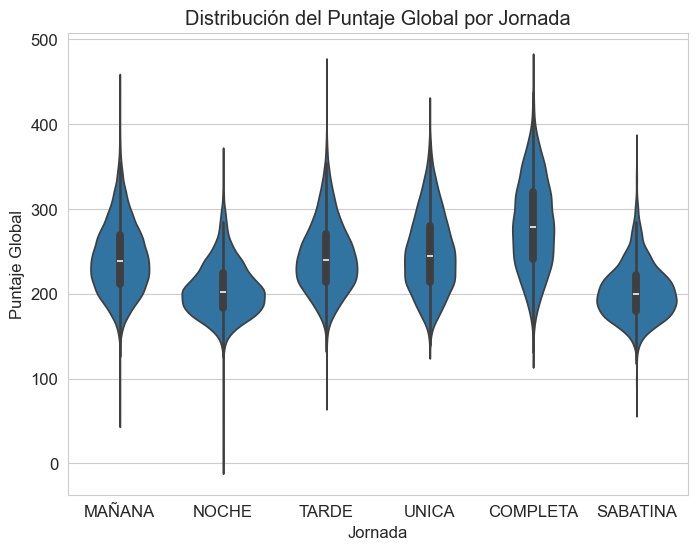

In [20]:
jorn= df["cole_jornada"].value_counts()
print(jorn)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_jornada", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Jornada")
plt.xlabel("Jornada")
plt.ylabel("Puntaje Global")
plt.show()


cole_naturaleza
OFICIAL       63075
NO OFICIAL    14500
Name: count, dtype: int64


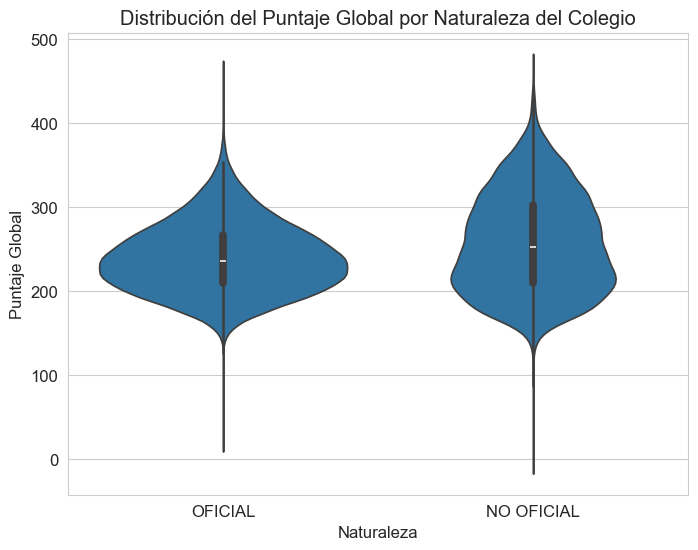

In [21]:
pub= df["cole_naturaleza"].value_counts()
print(pub)

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x="cole_naturaleza", y="punt_global",inner="box")

plt.title("Distribución del Puntaje Global por Naturaleza del Colegio")
plt.xlabel("Naturaleza")
plt.ylabel("Puntaje Global")
plt.show()

In [22]:
publico = df[df["cole_naturaleza"] == "OFICIAL"]["punt_global"]
privado = df[df["cole_naturaleza"] == "NO OFICIAL"]["punt_global"]

t_stat, p_value = stats.ttest_ind(publico, privado, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -33.8113504921533
p-value: 5.530424606393086e-243


In [23]:
pub= df["fami_educacionmadre"].value_counts()
print(pub)
print("-----------")
pub= df["fami_educacionpadre"].value_counts()
print(pub)


fami_educacionmadre
Secundaria (Bachillerato) completa      20544
Secundaria (Bachillerato) incompleta    11152
Primaria incompleta                     10821
Primaria completa                        8562
Educación profesional completa           7946
Técnica o tecnológica completa           7702
Ninguno                                  2535
Técnica o tecnológica incompleta         1860
Educación profesional incompleta         1465
No sabe                                  1309
Postgrado                                1078
No Aplica                                  76
Name: count, dtype: int64
-----------
fami_educacionpadre
Secundaria (Bachillerato) completa      19005
Primaria incompleta                     13101
Secundaria (Bachillerato) incompleta    10243
Primaria completa                        8716
Educación profesional completa           7373
Técnica o tecnológica completa           5393
Ninguno                                  4275
No sabe                                  2992
Té

<Figure size 1200x700 with 0 Axes>

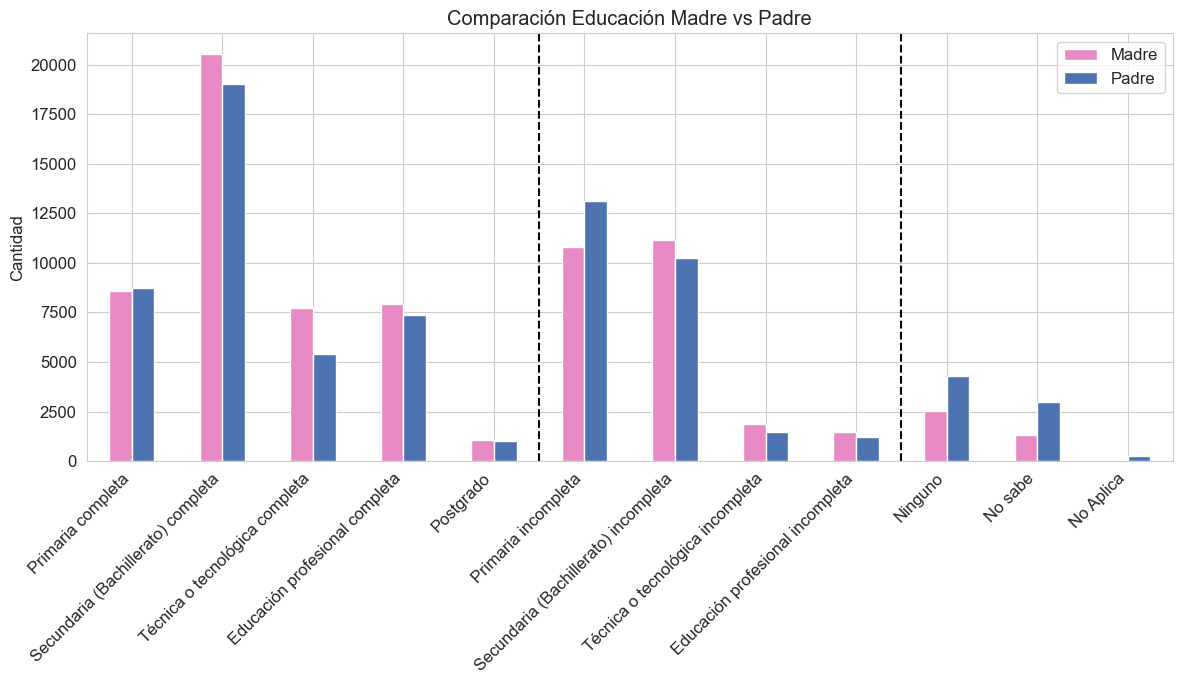

In [24]:
madre_counts = df["fami_educacionmadre"].value_counts()
padre_counts = df["fami_educacionpadre"].value_counts()

tabla = pd.DataFrame({
    "Madre": madre_counts,
    "Padre": padre_counts
}).fillna(0)

orden = ["Primaria completa", "Secundaria (Bachillerato) completa", "Técnica o tecnológica completa", "Educación profesional completa", "Postgrado",
                       
    "Primaria incompleta", "Secundaria (Bachillerato) incompleta", "Técnica o tecnológica incompleta", "Educación profesional incompleta",

    "Ninguno", "No sabe", "No Aplica"]
tabla = tabla.reindex(orden)

plt.figure(figsize=(12,7))
ax = tabla.plot(kind="bar", figsize=(12,7), color=["#E78AC3", "#4C72B0"])
plt.title("Comparación Educación Madre vs Padre")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.axvline(x=4.5, color='black', linestyle='--')
plt.axvline(x=8.5, color='black', linestyle='--')
plt.tight_layout()
plt.show()

In [25]:
#modelo RL
#punt_global= \beta_0 + \gamma_1*cole_naturaleza[oficial] + \gamma_2*cole_calendario[A] + \gamma_3*cole_area_ubicacion[RURAL] + \gamma_4*cole_jornada[MAÑANA]
#                     + \gamma_5*fami_educacion_madre[Educación profesional completa] + \gamma_6*fami_educacion_padre[Educación profesional completa] + \epsilon

modelo = smf.ols("""punt_global ~ C(cole_naturaleza, Treatment(reference="OFICIAL")) + C(cole_calendario, Treatment(reference="A")) +
C(cole_area_ubicacion, Treatment(reference="URBANO")) + C(cole_jornada, Treatment(reference="MAÑANA")) +
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa")) + 
C(fami_educacionpadre, Treatment(reference="Secundaria (Bachillerato) completa"))
""", data=df).fit(cov_type="HC3")




In [26]:
sm.stats.anova_lm(modelo, typ=2)

,sum_sq,df,F,PR(>F)
"C(cole_naturaleza, Treatment(reference=""OFICIAL""))",395527.350,1.000,249.175,0.000
"C(cole_calendario, Treatment(reference=""A""))",474333.115,1.000,298.821,0.000
"C(cole_area_ubicacion, Treatment(reference=""URBANO""))",1756125.458,1.000,1106.327,0.000
"C(cole_jornada, Treatment(reference=""MAÑANA""))",14415138.794,5.000,1816.255,0.000
"C(fami_educacionmadre, Treatment(reference=""Secundaria (Bachillerato) completa""))",2105271.140,11.000,120.571,0.000
"C(fami_educacionpadre, Treatment(reference=""Secundaria (Bachillerato) completa""))",1349648.933,11.000,77.296,0.000
Residual,118944727.775,74933.000,NaN,NaN


In [27]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            punt_global   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     811.4
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:11:42   Log-Likelihood:            -3.8259e+05
No. Observations:               74964   AIC:                         7.652e+05
Df Residuals:                   74933   BIC:                         7.655e+05
Df Model:                          30                                         
Covariance Type:                  HC3                                         
=============================================================================================================================================================================================
                                                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                                                   245.0602      0.376    651.305      0.000     244.323     245.798
C(cole_naturaleza, Treatment(reference="OFICIAL"))[T.NO OFICIAL]                                                              9.5907      0.608     15.785      0.000       8.400      10.782
C(cole_calendario, Treatment(reference="A"))[T.B]                                                                            41.2352      2.385     17.286      0.000      36.560      45.910
C(cole_area_ubicacion, Treatment(reference="URBANO"))[T.RURAL]                                                              -13.2907      0.400    -33.261      0.000     -14.074     -12.508
C(cole_jornada, Treatment(reference="MAÑANA"))[T.COMPLETA]                                                                   16.0152      0.684     23.403      0.000      14.674      17.356
C(cole_jornada, Treatment(reference="MAÑANA"))[T.NOCHE]                                                                     -34.7549      0.567    -61.270      0.000     -35.867     -33.643
C(cole_jornada, Treatment(reference="MAÑANA"))[T.SABATINA]                                                                  -46.7894      0.809    -57.870      0.000     -48.374     -45.205
C(cole_jornada, Treatment(reference="MAÑANA"))[T.TARDE]                                                                      -0.1148      0.400     -0.287      0.774      -0.898       0.669
C(cole_jornada, Treatment(reference="MAÑANA"))[T.UNICA]                                                                       4.8321      0.621      7.785      0.000       3.616       6.049
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.Educación profesional completa]          13.0412      0.666     19.577      0.000      11.736      14.347
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.Educación profesional incompleta]        13.5635      1.280     10.595      0.000      11.054      16.073
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.Ninguno]                                 -8.8558      0.847    -10.454      0.000     -10.516      -7.196
C(fami_educacionmadre, Treatment(reference="Secundaria (Bachillerato) completa"))[T.No Aplica]                              -27.3710      4.457     -6.141      0.000     -36.106     -18.635
C(fami_educacionmadre, Treatment(reference=

In [28]:
#pasarlo a tabla
coef = pd.DataFrame({
    "coef": modelo.params,
    "se": modelo.bse,
    "z": modelo.tvalues,
    "p": modelo.pvalues,
    "ci_low": modelo.conf_int()[0],
    "ci_high": modelo.conf_int()[1],
})
coef = coef.sort_values("p")
print(coef)

                                                      coef    se       z  \
Intercept                                          245.060 0.376 651.305   
C(cole_jornada, Treatment(reference="MAÑANA"))[... -34.755 0.567 -61.270   
C(cole_jornada, Treatment(reference="MAÑANA"))[... -46.789 0.809 -57.870   
C(cole_area_ubicacion, Treatment(reference="URB... -13.291 0.400 -33.261   
C(cole_jornada, Treatment(reference="MAÑANA"))[...  16.015 0.684  23.403   
C(fami_educacionmadre, Treatment(reference="Sec...  13.041 0.666  19.577   
C(cole_calendario, Treatment(reference="A"))[T.B]   41.235 2.385  17.286   
C(fami_educacionmadre, Treatment(reference="Sec...  26.736 1.642  16.281   
C(cole_naturaleza, Treatment(reference="OFICIAL...   9.591 0.608  15.785   
C(fami_educacionmadre, Treatment(reference="Sec...   9.124 0.580  15.720   
C(fami_educacionpadre, Treatment(reference="Sec...  24.518 1.690  14.509   
C(fami_educacionpadre, Treatment(reference="Sec...   9.626 0.684  14.072   
C(fami_educa